<a href="https://colab.research.google.com/github/tejsvinimeshram/Practical-.4/blob/main/EE524_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [ ]:
#step 1;
data = pd.read_csv("wireless_signal_quality_dataset.csv")
print("First Five Records")
print(data.head())
print("\rDataset Shape:", data.shape)

First Five Records
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2         

In [ ]:
#Step 2: Define Features and Target
X = data.drop('Quality', axis=1)
y = data['Quality']


In [ ]:
#step 3: Encode Target Labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nClass Labels:")
print(encoder.classes_)



Class Labels:
['Excellent' 'Fair' 'Good' 'Poor']


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
#step 6: Make Predictions
y_pred = dt.predict(x_test)

In [ ]:
#step 7: Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print ("\nAccuracy :{:.2f}%",format(accuracy*100))


Accuracy :{:.2f}% 80.0


In [ ]:
#step 8: confusion matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[ 0  0  1  0]
 [ 0  3  1  2]
 [ 0  0  3  0]
 [ 0  0  0 10]]


In [ ]:
#step 9: Classification Report
print(classification_report(y_test,y_pred,target_names=encoder.classes_.astype(str)))

              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       1.00      0.50      0.67         6
        Good       0.60      1.00      0.75         3
        Poor       0.83      1.00      0.91        10

    accuracy                           0.80        20
   macro avg       0.61      0.62      0.58        20
weighted avg       0.81      0.80      0.77        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#step 10: feature importance
importance=pd.Series(
    dt.feature_importances_,
    index=X.columns
)
importance=importance.sort_values(ascending=False)
print("\nfeature importance:")
print(importance)


feature importance:
Signal_Strength_dBm          0.524188
SNR_dB                       0.317104
Interference_dB              0.104255
Estimated_Throughput_Mbps    0.054452
Distance_m                   0.000000
Frequency_GHz                0.000000
Channel_Bandwidth_MHz        0.000000
Noise_Floor_dBm              0.000000
Connected_Devices            0.000000
dtype: float64


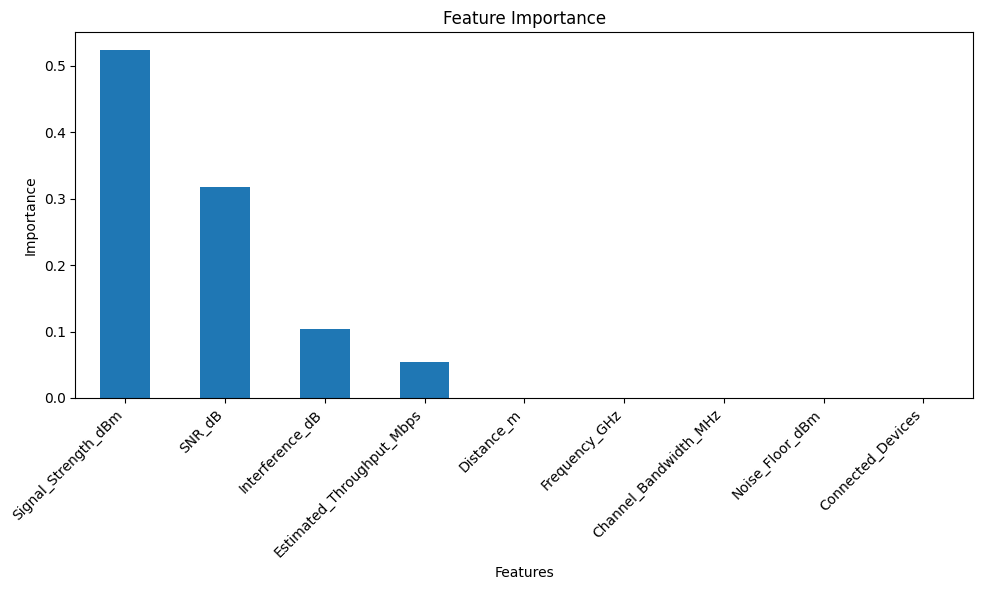

In [ ]:
#step 11: Plot Feature Importance
plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()